# 02. Uplift models and Qini evaluation

**Uplift Modeling and Targeting Policy** &nbsp;|&nbsp; Notebook 2 of 3

---

### What this notebook does

Builds two uplift estimators, tests whether probability calibration
helps, and evaluates both against the noise floor measured in
notebook 1.

Uplift is the change in a user's behaviour caused by the ad. It
cannot be observed for any individual, because each user either sees
the ad or does not, never both. So it is estimated for groups and
evaluated by ranking rather than by accuracy.

Four things come out of it:

1. A split design that keeps the scarce control-arm events balanced
   across train, validation and test
2. Two estimators that fail in opposite directions, and a diagnostic
   explaining which failed and why
3. A measured answer on whether calibration helps, rather than an
   assumed one
4. A Qini evaluation with a random-ranking band, so a rising curve
   means something

### Carried in from notebook 1

| Decision | Basis |
|---|---|
| Primary outcome is `visit` | Control-arm event counts and the noise floor |
| Intent to treat on `treatment` as assigned | `exposure` is post-treatment and not randomised |
| `exposure` excluded from every feature set | Same |
| Report at 20 bins | Finer bins raise the noise floor for no gain |
| Analytic standard errors are trustworthy | Observed spread matched prediction at every bin count |
| Noise floor on visit at 20 bins is 6.3% of the average effect | Any evaluation curve needs a band behind it |
| Common support holds | Uplift is measurable across the feature space |

### Data

Criteo Uplift Prediction dataset, version 2.1. Not included in this
repository. See notebook 1 for the download link, file hash and
citation.

### Runtime

`DEV_MODE = True` runs on a 20% sample in a few minutes, for checking
the pipeline. Every reported number comes from a full run with
`DEV_MODE = False`, which takes about 90 minutes: fifteen model fits
across five split seeds.

## Setup

In [3]:
import time
from pathlib import Path

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split

### Data

This notebook is self-contained and loads the file itself rather than
inheriting `df` from the step 1 notebook.

Same file, same dtypes, same exclusions as step 1. `exposure` is
loaded so the file reads cleanly but never enters a feature set.

In [4]:
DATA_PATH = Path("../Data/criteo-uplift-v2.1.csv.gz")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No file at {DATA_PATH.resolve()}. Check DATA_PATH."
    )

FEATURES = [f"f{i}" for i in range(12)]
TREATMENT_COL = "treatment"
BINARY_COLS = ["treatment", "visit", "conversion", "exposure"]

DTYPES = {name: "float32" for name in FEATURES}
DTYPES.update({name: "int8" for name in BINARY_COLS})

pd.set_option("display.width", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

In [5]:
df = pd.read_csv(DATA_PATH, compression="gzip", dtype=DTYPES)

print(f"rows: {len(df):,}")
print(f"treated share: {df[TREATMENT_COL].mean():.6f}")

rows: 13,979,592
treated share: 0.850000


### Run configuration

In [6]:
OUTCOME = "visit"

TRAIN_SIZE = 0.60
VALID_SIZE = 0.20
TEST_SIZE = 0.20

SPLIT_SEEDS = [101, 102, 103, 104, 105]

DEV_MODE = False
DEV_FRACTION = 0.20
DEV_SEED = 20260924

N_QINI_POINTS = 101
N_NOISE_DRAWS = 50
NOISE_SEED = 555

LGB_OUTCOME_PARAMS = {
    "objective": "binary",
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 500,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "n_jobs": -1,
    "verbose": -1,
}

EARLY_STOPPING_ROUNDS = 50

trapezoid = getattr(np, "trapezoid", getattr(np, "trapz", None))

print("lightgbm", lgb.__version__)
print("numpy", np.__version__)

lightgbm 4.6.0
numpy 2.4.1


## 1. Split design

### Why three parts and not two

Every number a model produces on data it was fitted to is optimistic,
because the model has already seen the answers. So results must be
read off data the model never touched.

Two parts would be enough if no decisions were made after fitting.
But decisions are made: when to stop adding trees, and how to
calibrate. Each of those uses data to make a choice. If those choices
are made on the same rows used to report the final number, the
reported number is optimistic again, in a smaller and less obvious
way.

Three parts, each with one job:

| Part | Share | Job |
|---|---|---|
| Train | 60% | Fit model parameters |
| Validation | 20% | Decide when to stop, and fit calibration |
| Test | 20% | Report results. Touched once |

### Why the split is stratified, and on what

A plain random split gives each part roughly the right mix by chance.
Roughly is not the same as exactly, and for this data the thing that
varies is the thing that matters.

Stratifying means splitting each subgroup separately and combining,
so the proportions are held fixed by construction rather than left to
chance.

Two variables have to be held fixed together:

- `treatment`, so each part keeps the 85/15 arm split. A part with
  fewer control rows has a higher noise floor.
- `visit`, so each part keeps the same event rate. Visits are 4.7% of
  rows, and it is the events that carry the information.

Stratifying on the combination gives four strata: treated visitors,
treated non-visitors, control visitors, control non-visitors. The
scarcest of these, control visitors, is the one the whole analysis
rests on, so it is the one worth protecting.

### Why the test share is 20% and not smaller

The test set is where the noise floor from step 1 applies. At 20% of
14M rows, the test set holds about 2.8M rows, roughly 419,000 of them
control, carrying about 16,000 control visits. Spread over 20 bins
that is 800 control visits per bin, which is enough for a readable
curve.

Going smaller to buy training rows would raise the noise floor on the
one number the project reports.

In [7]:
def stratified_three_way_split(frame, outcome, seed,
                               train_size=TRAIN_SIZE,
                               valid_size=VALID_SIZE):
    """Split into train, validation and test, stratified.

    Strata are the combination of treatment arm and outcome, so all
    three parts keep the same arm ratio and the same event rate.

    Args:
        frame (pandas.DataFrame): Full dataset.
        outcome (str): Binary outcome column name.
        seed (int): Seed for the split.
        train_size (float): Share for training.
        valid_size (float): Share for validation.

    Returns:
        tuple: Three index arrays, for train, validation and test.
    """
    strata = (frame["treatment"].astype(str)
              + "_" + frame[outcome].astype(str))
    indices = np.arange(len(frame))

    train_index, holdout_index = train_test_split(
        indices,
        train_size=train_size,
        stratify=strata,
        random_state=seed,
    )

    holdout_strata = strata.to_numpy()[holdout_index]
    valid_share = valid_size / (1 - train_size)

    valid_index, test_index = train_test_split(
        holdout_index,
        train_size=valid_share,
        stratify=holdout_strata,
        random_state=seed,
    )

    return train_index, valid_index, test_index

In [8]:
def describe_split(frame, outcome, parts):
    """Report arm ratio and event rate for each part of a split.

    Args:
        frame (pandas.DataFrame): Full dataset.
        outcome (str): Binary outcome column name.
        parts (dict): Part name mapped to an index array.

    Returns:
        pandas.DataFrame: One row per part.
    """
    rows = []
    for name, index in parts.items():
        subset = frame.iloc[index]
        treated = subset[subset["treatment"] == 1]
        control = subset[subset["treatment"] == 0]
        rows.append({
            "part": name,
            "rows": len(subset),
            "treated_share": subset["treatment"].mean(),
            "outcome_rate": subset[outcome].mean(),
            "control_rows": len(control),
            "control_positives": int(control[outcome].sum()),
            "treated_positives": int(treated[outcome].sum()),
        })
    return pd.DataFrame(rows)

### Development sample

Fitting on 14M rows takes minutes per model, and this notebook fits
three models per seed across five seeds. That is slow to iterate
against.

`DEV_MODE` runs everything on a 20% random sample so the pipeline can
be debugged in a few minutes. The sample preserves the arm ratio,
which is correct here because it is only being used to check that the
code runs.

Every reported number comes from a full-data run with
`DEV_MODE = False`. The sample never enters a result.

In [9]:
if DEV_MODE:
    working = df.sample(frac=DEV_FRACTION, random_state=DEV_SEED)
    working = working.reset_index(drop=True)
else:
    working = df

print(f"working rows: {len(working):,}")
print(f"dev mode: {DEV_MODE}")

working rows: 13,979,592
dev mode: False


In [10]:
train_index, valid_index, test_index = stratified_three_way_split(
    working, OUTCOME, SPLIT_SEEDS[0]
)

describe_split(working, OUTCOME, {
    "train": train_index,
    "valid": valid_index,
    "test": test_index,
})

,part,rows,treated_share,outcome_rate,control_rows,control_positives,treated_positives
0,train,8387755,0.850000,0.046992,1258162,48063,346094
1,valid,2795918,0.850000,0.046992,419387,16021,115365
2,test,2795919,0.850000,0.046992,419388,16021,115365


Read the `treated_share` and `outcome_rate` columns across the three
rows. They should agree to several decimal places. If they do not,
the stratification did not take effect and everything downstream
inherits the problem.

## 2. The two uplift estimators

### The problem both are solving

Uplift for a user is the difference between what they would do if
advertised to and what they would do if not. Only one of those is
ever observed for any individual, so uplift cannot be read off the
data directly. It has to be assembled from two things that can be
estimated.

### Estimator A. Two models, one per arm

Also called a T-learner, T for two.

Fit one model on treated users only, predicting the outcome. Fit a
second model on control users only, predicting the outcome. For any
user, predict with both and subtract.

```
uplift(x) = p_treated(x) - p_control(x)
```

What it gets right: each model has a clean, well-posed job. Nothing
about the treated arm can contaminate the control model.

Where it is fragile here: the control model sees only 15% of the
data, about 1.26M rows in training with roughly 48,000 visits. And
the quantity being estimated is a difference of about 0.010 between
two numbers around 0.04. Each model only has to be slightly wrong in
opposite directions to distort a difference that small.

### Estimator B. One model with treatment as an input

Also called an S-learner, S for single.

Fit one model on everyone, giving it `treatment` as a thirteenth
feature alongside `f0` to `f11`. Then, for any user, predict twice:
once with the treatment input forced to 1, once forced to 0. Subtract.

```
uplift(x) = p(x, treatment=1) - p(x, treatment=0)
```

What it gets right: all 14M rows train one model, so the shared
structure between arms is learned once, from everything.

Where it is fragile: nothing forces the model to use the treatment
input. A gradient boosting model builds trees by repeatedly choosing
the split that most reduces error. `treatment` shifts the visit rate
from 3.8% to 4.9%. Other features may reduce error more at every
step. If the model rarely splits on `treatment`, then forcing it to 1
and to 0 produces nearly the same prediction, and every uplift score
collapses towards zero.

That is a known failure mode, not a hypothetical. The check is
whether `treatment` appears in the model's split counts at all.

### Why compare them rather than pick one

They fail in opposite directions. The two-model approach is noisy
because it estimates a small difference from two separately estimated
numbers. The single-model approach is biased towards zero because it
may decline to use the treatment input.

Running both and reporting both is the honest answer to the question
of which is right for this data, and the comparison itself is the
finding.

In [11]:
def fit_outcome_model(features_train, labels_train,
                      features_valid, labels_valid,
                      params, seed):
    """Fit one LightGBM outcome model with early stopping.

    Args:
        features_train (pandas.DataFrame): Training features.
        labels_train (numpy.ndarray): Training labels.
        features_valid (pandas.DataFrame): Validation features.
        labels_valid (numpy.ndarray): Validation labels.
        params (dict): LightGBM parameters.
        seed (int): Seed for the learner.

    Returns:
        lightgbm.LGBMClassifier: The fitted model.
    """
    model = lgb.LGBMClassifier(random_state=seed, **params)
    model.fit(
        features_train,
        labels_train,
        eval_set=[(features_valid, labels_valid)],
        eval_metric="binary_logloss",
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)
        ],
    )
    return model

In [12]:
def fit_two_model(frame, features, outcome, train_index,
                  valid_index, params, seed):
    """Fit the two-model (T-learner) uplift estimator.

    Args:
        frame (pandas.DataFrame): Working dataset.
        features (list): Feature column names.
        outcome (str): Binary outcome column name.
        train_index (numpy.ndarray): Training row positions.
        valid_index (numpy.ndarray): Validation row positions.
        params (dict): LightGBM parameters.
        seed (int): Seed for the learners.

    Returns:
        dict: Fitted treated and control models.
    """
    train = frame.iloc[train_index]
    valid = frame.iloc[valid_index]

    models = {}
    for arm, flag in [("treated", 1), ("control", 0)]:
        train_arm = train[train["treatment"] == flag]
        valid_arm = valid[valid["treatment"] == flag]
        models[arm] = fit_outcome_model(
            train_arm[features],
            train_arm[outcome].to_numpy(),
            valid_arm[features],
            valid_arm[outcome].to_numpy(),
            params,
            seed,
        )
    return models


def predict_two_model(models, features_frame):
    """Predict arm probabilities from a fitted two-model estimator.

    Args:
        models (dict): Fitted treated and control models.
        features_frame (pandas.DataFrame): Feature columns.

    Returns:
        tuple: Treated and control predicted probabilities.
    """
    p_treated = models["treated"].predict_proba(features_frame)[:, 1]
    p_control = models["control"].predict_proba(features_frame)[:, 1]
    return p_treated, p_control

In [13]:
def fit_single_model(frame, features, outcome, train_index,
                     valid_index, params, seed):
    """Fit the single-model (S-learner) uplift estimator.

    Args:
        frame (pandas.DataFrame): Working dataset.
        features (list): Feature column names.
        outcome (str): Binary outcome column name.
        train_index (numpy.ndarray): Training row positions.
        valid_index (numpy.ndarray): Validation row positions.
        params (dict): LightGBM parameters.
        seed (int): Seed for the learner.

    Returns:
        lightgbm.LGBMClassifier: The fitted model.
    """
    columns = list(features) + ["treatment"]
    train = frame.iloc[train_index]
    valid = frame.iloc[valid_index]

    return fit_outcome_model(
        train[columns],
        train[outcome].to_numpy(),
        valid[columns],
        valid[outcome].to_numpy(),
        params,
        seed,
    )


def predict_single_model(model, features_frame, features):
    """Predict both arm probabilities from a single model.

    The treatment input is forced to 1 and then to 0, holding every
    other feature at its observed value.

    Args:
        model (lightgbm.LGBMClassifier): Fitted model.
        features_frame (pandas.DataFrame): Feature columns.
        features (list): Feature column names.

    Returns:
        tuple: Treated and control predicted probabilities.
    """
    columns = list(features) + ["treatment"]

    as_treated = features_frame[features].copy()
    as_treated["treatment"] = 1
    as_control = features_frame[features].copy()
    as_control["treatment"] = 0

    p_treated = model.predict_proba(as_treated[columns])[:, 1]
    p_control = model.predict_proba(as_control[columns])[:, 1]
    return p_treated, p_control

### The check that decides whether the single model is usable

In [14]:
def treatment_split_share(model, features):
    """Share of the model's splits that used the treatment input.

    Args:
        model (lightgbm.LGBMClassifier): Fitted single model.
        features (list): Feature column names.

    Returns:
        dict: Split counts and the treatment share of them.
    """
    columns = list(features) + ["treatment"]
    importance = pd.Series(
        model.booster_.feature_importance(importance_type="split"),
        index=columns,
    )
    total = importance.sum()
    return {
        "treatment_splits": int(importance["treatment"]),
        "total_splits": int(total),
        "treatment_share": float(importance["treatment"] / total),
        "expected_share_if_uniform": 1 / len(columns),
    }

If `treatment_splits` is zero or close to it, the single model has
declined to use the treatment input, its uplift scores are near zero
everywhere, and the estimator has failed on this data. That is a
reportable result, not a bug to work around.

## 3. Calibration, and why it comes before evaluation

### What calibration means

A model that outputs 0.04 for a group of users is calibrated if
roughly 4% of those users actually visit. Models are often ranked
correctly while being wrong about levels: a model can reliably say
which users are more likely to visit while systematically
overstating everyone's probability.

Isotonic regression fixes levels without disturbing order. It learns
a step function, fitted on held-out data, mapping predicted
probabilities to observed rates. It is monotone by construction, so a
user with a higher raw score keeps a higher corrected score.

### Why it matters here, and it is not the obvious reason

For a single model that ranks users, calibration changes nothing
about the ranking, so evaluation by ranking is unaffected.

Uplift is different, because two models are involved.

The two-model estimator applies one correction to the treated model
and a different correction to the control model. Each correction is
monotone on its own. The difference between two differently corrected
numbers is not guaranteed to preserve the original ordering of the
difference.

Concretely: user A might have a raw uplift of 0.012 and user B 0.010,
and after calibration A could sit below B. The ranking is the thing
Qini measures. So calibration can change the evaluation result, which
means it has to be settled before evaluation rather than bolted on
afterwards for the profit calculation later.

The way to settle it is to measure it. Both versions are scored
below.

### Where the calibration is fitted

On the validation set, never on train and never on test. The treated
model's correction is fitted on validation treated rows only, the
control model's on validation control rows only. Each correction has
to be learned from the arm it will be applied to.

In [15]:
def fit_calibrators(p_treated_valid, p_control_valid,
                    treatment_valid, outcome_valid):
    """Fit one isotonic calibrator per arm on validation rows.

    Args:
        p_treated_valid (numpy.ndarray): Treated-model predictions on
            validation rows.
        p_control_valid (numpy.ndarray): Control-model predictions on
            validation rows.
        treatment_valid (numpy.ndarray): Validation treatment flags.
        outcome_valid (numpy.ndarray): Validation outcomes.

    Returns:
        dict: Fitted calibrators for each arm.
    """
    is_treated = treatment_valid == 1
    is_control = ~is_treated

    treated_calibrator = IsotonicRegression(
        y_min=0, y_max=1, out_of_bounds="clip")
    treated_calibrator.fit(
        p_treated_valid[is_treated], outcome_valid[is_treated])

    control_calibrator = IsotonicRegression(
        y_min=0, y_max=1, out_of_bounds="clip")
    control_calibrator.fit(
        p_control_valid[is_control], outcome_valid[is_control])

    return {
        "treated": treated_calibrator,
        "control": control_calibrator,
    }


def apply_calibrators(calibrators, p_treated, p_control):
    """Apply fitted calibrators to arm probabilities.

    Args:
        calibrators (dict): Fitted calibrators for each arm.
        p_treated (numpy.ndarray): Treated-model predictions.
        p_control (numpy.ndarray): Control-model predictions.

    Returns:
        tuple: Calibrated treated and control probabilities.
    """
    return (
        calibrators["treated"].predict(p_treated),
        calibrators["control"].predict(p_control),
    )

### Reading a calibration table without fooling yourself

The obvious way to check calibration is to bin the raw predictions,
print predicted against observed, then do the same for the calibrated
predictions and compare the two tables.

That comparison is invalid, and the reason is worth understanding
because it is not obvious.

Isotonic regression outputs a step function. It maps a continuous
range of predictions down to a small number of distinct output
values. On a test of 400,000 rows, isotonic collapsed 400,000 unique
predictions to 62 unique values.

Quantile binning on a variable with heavy ties cannot produce equal
bins. `pd.qcut` drops duplicate boundaries, so a request for 20 bins
returns fewer, of wildly uneven size. In that same test, binning the
raw predictions gave 20 bins of exactly 20,000 rows each. Binning the
calibrated predictions gave 15 bins ranging from 14,234 to 44,537
rows.

Two tables built that way group different users into each row. Row 14
of one is not row 14 of the other, so reading them side by side
compares nothing.

The fix is to define the bins once, on the raw predictions, and carry
both columns through the same grouping. Every user then stays in the
same bin in both columns, and the comparison is real.

In [16]:
def calibration_comparison(raw, calibrated, outcomes, n_bins=20):
    """Compare raw and calibrated predictions within fixed bins.

    Bins are defined once, on the raw predictions, so each row stays
    in the same bin for both columns.

    Args:
        raw (numpy.ndarray): Uncalibrated predictions.
        calibrated (numpy.ndarray): Calibrated predictions.
        outcomes (numpy.ndarray): Observed binary outcomes.
        n_bins (int): Number of equal-count bins.

    Returns:
        pandas.DataFrame: One row per bin, with both predictions and
        the observed rate.
    """
    frame = pd.DataFrame({
        "raw": raw,
        "calibrated": calibrated,
        "observed": outcomes,
    })
    frame["bin"] = pd.qcut(
        frame["raw"], n_bins, labels=False, duplicates="drop")

    table = frame.groupby("bin").agg(
        rows=("observed", "size"),
        raw_mean=("raw", "mean"),
        calibrated_mean=("calibrated", "mean"),
        observed_rate=("observed", "mean"),
    ).reset_index()

    table["raw_error"] = (table["raw_mean"]
                          - table["observed_rate"]).abs()
    table["calibrated_error"] = (table["calibrated_mean"]
                                 - table["observed_rate"]).abs()
    return table

## 4. Qini, the evaluation metric

### The theory, built up from the problem

You need a way to score a set of uplift predictions. Ordinary
accuracy measures cannot be used, because the quantity being
predicted is never observed for anyone. There is no column of true
uplift values to compare against.

So the scoring has to work on groups instead of individuals.

The idea: sort everyone by predicted uplift, best first. Walk down
that list. At each point, look at everyone you have passed so far and
ask how many extra visits the campaign produced within that group.

If the predictions are good, the users at the top are the ones the
campaign helps most, so the extra visits accumulate quickly at the
start and level off later. If the predictions are worthless, the
extra visits accumulate at a steady rate all the way down, because
every part of the list is the same as any other.

### How the number at each point is computed

Among the first n users on the list, count visits separately by arm:

- `visits_treated`, from the treated users in that group
- `visits_control`, from the control users in that group
- `n_treated` and `n_control`, the counts of each

The control group is smaller, so its visits cannot be subtracted
directly. Scale it up to what it would have produced at treated-group
size:

```
gains(n) = visits_treated - visits_control * (n_treated / n_control)
```

That is the estimated number of extra visits caused by the campaign
within the first n users. Plotting it against n gives the Qini curve.

### The reference line

At the far right, n is everyone, and `gains` equals the total number
of extra visits the campaign produced across the whole population.
Every ranking reaches that same endpoint, good or bad, because at
100% the ordering no longer matters.

So a curve is judged by how it gets there, not where it ends.

A worthless ranking traces a straight line from the origin to that
endpoint, because each successive slice contributes its proportional
share. A useful ranking bulges above the line: it collects the extra
visits early.

The **Qini coefficient** is the area between the curve and that
straight line. Larger is better. Zero means no better than arbitrary.

### The noise band, which is the part most write-ups omit

Step 1 established that random bin assignment produces apparent
uplift differences of about 6.3% of the average effect at 20 bins.
The same thing happens here. A ranking built from random numbers does
not trace a perfectly straight line. It wanders above and below.

So a Qini coefficient above zero is not evidence of anything on its
own. The question is whether it is above what random rankings
produce.

Same solution as checks 7 and 8. Generate 50 random score vectors,
compute a full Qini curve for each, and keep them. Two uses:

- Shade the region those curves occupy and draw the model's curve on
  top. If the model curve sits inside the shading, it found nothing.
- Collect the 50 random Qini coefficients into a null distribution
  and see where the model's coefficient falls.

This is the same method used three times now, which is deliberate.
One idea, applied consistently, is easier to defend than three
different significance procedures.

In [17]:
def qini_points(uplift_scores, treatment, outcome,
                n_points=N_QINI_POINTS, seed=0):
    """Compute a Qini curve from predicted uplift scores.

    Ties in the scores are broken at random rather than by row order,
    so that a constant score vector produces an arbitrary ranking
    instead of the dataset's own ordering.

    Args:
        uplift_scores (numpy.ndarray): Predicted uplift per row.
        treatment (numpy.ndarray): Binary treatment flags.
        outcome (numpy.ndarray): Binary outcomes.
        n_points (int): Number of points sampled along the curve.
        seed (int): Seed for tie breaking.

    Returns:
        tuple: Population fraction and cumulative incremental
        outcomes at each point.
    """
    rng = np.random.default_rng(seed)
    tie_breaker = rng.permutation(len(uplift_scores))
    order = np.lexsort((tie_breaker, -np.asarray(uplift_scores)))

    treated_flag = np.asarray(treatment)[order].astype(np.int64)
    response = np.asarray(outcome)[order].astype(np.int64)

    n_treated = np.cumsum(treated_flag)
    n_control = np.cumsum(1 - treated_flag)
    y_treated = np.cumsum(response * treated_flag)
    y_control = np.cumsum(response * (1 - treated_flag))

    ratio = np.divide(
        n_treated,
        n_control,
        out=np.zeros(len(treated_flag), dtype=float),
        where=n_control > 0,
    )
    gains = y_treated - y_control * ratio

    n_rows = len(treated_flag)
    positions = np.linspace(0, n_rows, n_points).astype(int)
    positions[0] = 1

    fraction = np.concatenate(([0.0], positions / n_rows))
    values = np.concatenate(([0.0], gains[positions - 1]))
    return fraction, values


def qini_coefficient(fraction, values):
    """Area between a Qini curve and its straight reference line.

    Args:
        fraction (numpy.ndarray): Population fraction at each point.
        values (numpy.ndarray): Cumulative incremental outcomes.

    Returns:
        float: The Qini coefficient, in incremental outcomes.
    """
    reference = fraction * values[-1]
    return float(trapezoid(values - reference, fraction))

In [18]:
def qini_noise_null(treatment, outcome, n_draws=N_NOISE_DRAWS,
                    n_points=N_QINI_POINTS, seed=NOISE_SEED):
    """Build Qini curves and coefficients from random rankings.

    Each draw scores rows at random, so any departure from the
    straight reference line is noise.

    Args:
        treatment (numpy.ndarray): Binary treatment flags.
        outcome (numpy.ndarray): Binary outcomes.
        n_draws (int): Number of random rankings.
        n_points (int): Number of points per curve.
        seed (int): Seed for the draw sequence.

    Returns:
        tuple: Fraction grid, an array of curves with one row per
        draw, and an array of coefficients.
    """
    rng = np.random.default_rng(seed)

    curves = []
    coefficients = []
    fraction = None

    for draw in range(n_draws):
        scores = rng.random(len(treatment))
        fraction, values = qini_points(
            scores, treatment, outcome, n_points, seed=seed + draw)
        curves.append(values)
        coefficients.append(qini_coefficient(fraction, values))

    return fraction, np.vstack(curves), np.array(coefficients)

## 5. One full run

Everything above, assembled for a single split seed. The repeated-seed
version follows.

In [19]:
def run_one_seed(frame, features, outcome, seed, params):
    """Fit both estimators on one split and evaluate on test.

    Args:
        frame (pandas.DataFrame): Working dataset.
        features (list): Feature column names.
        outcome (str): Binary outcome column name.
        seed (int): Seed for the split and the learners.
        params (dict): LightGBM parameters.

    Returns:
        dict: Test-set uplift scores per estimator and per
        calibration state, plus diagnostics.
    """
    started = time.time()

    train_index, valid_index, test_index = (
        stratified_three_way_split(frame, outcome, seed))

    valid = frame.iloc[valid_index]
    test = frame.iloc[test_index]

    treatment_valid = valid["treatment"].to_numpy()
    outcome_valid = valid[outcome].to_numpy()

    scores = {}
    diagnostics = {"seed": seed}

    two_model = fit_two_model(
        frame, features, outcome, train_index, valid_index,
        params, seed)

    p_t_valid, p_c_valid = predict_two_model(two_model, valid[features])
    p_t_test, p_c_test = predict_two_model(two_model, test[features])

    scores[("two_model", "raw")] = p_t_test - p_c_test

    calibrators = fit_calibrators(
        p_t_valid, p_c_valid, treatment_valid, outcome_valid)
    p_t_cal, p_c_cal = apply_calibrators(
        calibrators, p_t_test, p_c_test)
    scores[("two_model", "calibrated")] = p_t_cal - p_c_cal

    single_model = fit_single_model(
        frame, features, outcome, train_index, valid_index,
        params, seed)

    s_t_valid, s_c_valid = predict_single_model(
        single_model, valid, features)
    s_t_test, s_c_test = predict_single_model(
        single_model, test, features)

    scores[("single_model", "raw")] = s_t_test - s_c_test

    single_calibrators = fit_calibrators(
        s_t_valid, s_c_valid, treatment_valid, outcome_valid)
    s_t_cal, s_c_cal = apply_calibrators(
        single_calibrators, s_t_test, s_c_test)
    scores[("single_model", "calibrated")] = s_t_cal - s_c_cal

    diagnostics.update(treatment_split_share(single_model, features))
    diagnostics["seconds"] = time.time() - started

    return {
        "scores": scores,
        "diagnostics": diagnostics,
        "test_treatment": test["treatment"].to_numpy(),
        "test_outcome": test[outcome].to_numpy(),
        "calibration_inputs": {
            "two_model_raw_treated": p_t_test,
            "two_model_cal_treated": p_t_cal,
            "test_outcome": test[outcome].to_numpy(),
            "test_treatment": test["treatment"].to_numpy(),
        },
    }


run = run_one_seed(working, FEATURES, OUTCOME, SPLIT_SEEDS[0],
                   LGB_OUTCOME_PARAMS)

pd.Series(run["diagnostics"])

seed                           101.000000
treatment_splits               519.000000
total_splits                30,938.000000
treatment_share                  0.016775
expected_share_if_uniform        0.076923
seconds                        702.448067
dtype: float64

Check `treatment_share` in that output before reading anything else.
It is the share of the single model's splits that used the treatment
input. Near zero means the single-model estimator has collapsed.

### What the raw predictions look like

Before comparing anything, check the shape of the raw predictions.

The treated arm visits at 4.85%, so the mean prediction from a
sensible treated model should sit near 0.0485. If the mean is close
but the median is far below it, the predictions are right skewed with
a thin high tail, and quantile bins will hide that tail. If the mean
itself is far from 0.0485, something is wrong with the fit rather
than with the binning.

In [20]:
inputs = run["calibration_inputs"]
treated_rows = inputs["test_treatment"] == 1

raw_treated = inputs["two_model_raw_treated"][treated_rows]
cal_treated = inputs["two_model_cal_treated"][treated_rows]
observed_treated = inputs["test_outcome"][treated_rows]

pd.DataFrame({
    "raw": pd.Series(raw_treated).describe(
        percentiles=[0.01, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999]),
    "calibrated": pd.Series(cal_treated).describe(
        percentiles=[0.01, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999]),
})

,raw,calibrated
count,"2,376,531.000000","2,376,531.000000"
mean,0.048401,0.048611
std,0.125121,0.125732
min,0.000246,0.000000
1%,0.000404,0.000215
25%,0.000772,0.000751
50%,0.003328,0.003780
75%,0.018477,0.017608
90%,0.142763,0.153508
99%,0.645449,0.641211


In [21]:
print(f"observed treated visit rate: {observed_treated.mean():.6f}")
print(f"mean raw prediction:         {raw_treated.mean():.6f}")
print(f"mean calibrated prediction:  {cal_treated.mean():.6f}")
print(f"unique raw values:           {len(np.unique(raw_treated)):,}")
print(f"unique calibrated values:    {len(np.unique(cal_treated)):,}")

observed treated visit rate: 0.048543
mean raw prediction:         0.048401
mean calibrated prediction:  0.048611
unique raw values:           668,034
unique calibrated values:    384


### Did calibration improve the levels

In [22]:
calibration_comparison(raw_treated, cal_treated, observed_treated)

,bin,rows,raw_mean,calibrated_mean,observed_rate,raw_error,calibrated_error
0,0,121483,0.000452,0.000348,0.000305,0.000147,0.000044
1,1,121728,0.000529,0.000463,0.000641,0.000112,0.000177
2,2,113524,0.000573,0.000514,0.000546,0.000027,0.000032
3,3,119083,0.000620,0.000598,0.000546,0.000074,0.000052
4,4,118575,0.000713,0.000654,0.000590,0.000123,0.000064
5,5,118786,0.000827,0.000866,0.000825,0.000002,0.000041
6,6,118663,0.000988,0.001078,0.000935,0.000053,0.000143
7,7,118933,0.001289,0.001203,0.001312,0.000023,0.000108
8,8,118664,0.001730,0.001812,0.001862,0.000133,0.000050
9,9,119096,0.002653,0.002814,0.002737,0.000085,0.000077


Read `observed_rate` as the truth for each bin. Whichever of
`raw_mean` and `calibrated_mean` sits closer to it is the better
version, and the two error columns state that difference directly.

If `raw_error` is already small across every bin, calibration had
little to fix. That is a reportable finding rather than a
disappointment, and it appeared in the fraud project too.

In [23]:
summary = calibration_comparison(
    raw_treated, cal_treated, observed_treated)

pd.Series({
    "mean_abs_error_raw": summary["raw_error"].mean(),
    "mean_abs_error_calibrated": summary["calibrated_error"].mean(),
    "bins_improved": int(
        (summary["calibrated_error"] < summary["raw_error"]).sum()),
    "bins_total": len(summary),
})

mean_abs_error_raw           0.000278
mean_abs_error_calibrated    0.000346
bins_improved                9.000000
bins_total                  20.000000
dtype: float64

### Qini against the noise band

In [24]:
noise_fraction, noise_curves, noise_coefficients = qini_noise_null(
    run["test_treatment"], run["test_outcome"]
)

rows = []
for (estimator, state), values in run["scores"].items():
    fraction, curve = qini_points(
        values, run["test_treatment"], run["test_outcome"])
    coefficient = qini_coefficient(fraction, curve)
    rows.append({
        "estimator": estimator,
        "calibration": state,
        "qini": coefficient,
        "noise_mean": noise_coefficients.mean(),
        "noise_sd": noise_coefficients.std(ddof=1),
        "noise_p95": np.percentile(noise_coefficients, 95),
        "qini_over_noise_p95": coefficient / np.percentile(
            noise_coefficients, 95),
        "share_of_noise_beaten": float(
            (noise_coefficients < coefficient).mean()),
    })

pd.DataFrame(rows)

,estimator,calibration,qini,noise_mean,noise_sd,noise_p95,qini_over_noise_p95,share_of_noise_beaten
0,two_model,raw,"8,296.522688",-9.147685,186.985630,224.811752,36.904310,1.000000
1,two_model,calibrated,"8,556.154952",-9.147685,186.985630,224.811752,38.059198,1.000000
2,single_model,raw,"8,740.578825",-9.147685,186.985630,224.811752,38.879546,1.000000
3,single_model,calibrated,"8,987.897880",-9.147685,186.985630,224.811752,39.979662,1.000000


### How to read that table

| Column | Meaning |
|---|---|
| `qini` | Area between the model curve and the straight reference line, in incremental visits |
| `noise_mean` | Where random rankings land. Should sit near zero |
| `noise_p95` | The best a random ranking managed in 19 out of 20 draws |
| `qini_over_noise_p95` | Above 1 means the model beat what chance produces. Below 1 means it did not |
| `share_of_noise_beaten` | 1.00 means the model beat all 50 random rankings |

A model whose `qini_over_noise_p95` is below 1 has not demonstrated
anything, no matter how its curve looks by eye.

## 6. Repeated seeds

One split is one draw. The split itself is random, so the Qini
coefficient it produces carries its own sampling variation.

Repeating the whole pipeline across five split seeds gives a spread.
If the ranking of the two estimators flips between seeds, then the
difference between them is not real and the write-up should say so
rather than reporting whichever seed came first.

In [25]:
def run_all_seeds(frame, features, outcome, seeds, params):
    """Run the full pipeline once per split seed.

    Args:
        frame (pandas.DataFrame): Working dataset.
        features (list): Feature column names.
        outcome (str): Binary outcome column name.
        seeds (list): Split seeds.
        params (dict): LightGBM parameters.

    Returns:
        tuple: Results frame and diagnostics frame.
    """
    result_rows = []
    diagnostic_rows = []

    for seed in seeds:
        run = run_one_seed(frame, features, outcome, seed, params)
        diagnostic_rows.append(run["diagnostics"])

        _, _, noise_coefficients = qini_noise_null(
            run["test_treatment"], run["test_outcome"],
            seed=NOISE_SEED + seed,
        )

        for (estimator, state), values in run["scores"].items():
            fraction, curve = qini_points(
                values, run["test_treatment"], run["test_outcome"])
            coefficient = qini_coefficient(fraction, curve)
            result_rows.append({
                "seed": seed,
                "estimator": estimator,
                "calibration": state,
                "qini": coefficient,
                "noise_p95": np.percentile(noise_coefficients, 95),
                "qini_over_noise_p95": coefficient / np.percentile(
                    noise_coefficients, 95),
                "share_of_noise_beaten": float(
                    (noise_coefficients < coefficient).mean()),
            })

    return pd.DataFrame(result_rows), pd.DataFrame(diagnostic_rows)


results, diagnostics = run_all_seeds(
    working, FEATURES, OUTCOME, SPLIT_SEEDS, LGB_OUTCOME_PARAMS)

results

,seed,estimator,calibration,qini,noise_p95,qini_over_noise_p95,share_of_noise_beaten
0,101,two_model,raw,"8,296.522688",373.341169,22.222362,1.000000
1,101,two_model,calibrated,"8,556.154952",373.341169,22.917791,1.000000
2,101,single_model,raw,"8,740.578825",373.341169,23.411773,1.000000
3,101,single_model,calibrated,"8,987.897880",373.341169,24.074221,1.000000
4,102,two_model,raw,"8,508.361883",348.358127,24.424181,1.000000
5,102,two_model,calibrated,"8,541.606565",348.358127,24.519613,1.000000
6,102,single_model,raw,"9,152.378378",348.358127,26.272900,1.000000
7,102,single_model,calibrated,"8,920.353330",348.358127,25.606847,1.000000
8,103,two_model,raw,"8,859.397716",337.512254,26.249114,1.000000
9,103,two_model,calibrated,"8,955.428451",337.512254,26.533639,1.000000


In [26]:
results.groupby(["estimator", "calibration"]).agg(
    qini_mean=("qini", "mean"),
    qini_sd=("qini", "std"),
    qini_min=("qini", "min"),
    qini_max=("qini", "max"),
    over_noise_mean=("qini_over_noise_p95", "mean"),
    noise_beaten_mean=("share_of_noise_beaten", "mean"),
).reset_index()

,estimator,calibration,qini_mean,qini_sd,qini_min,qini_max,over_noise_mean,noise_beaten_mean
0,single_model,calibrated,"8,862.840820",294.044901,"8,356.852667","9,120.931793",25.502498,1.000000
1,single_model,raw,"9,055.322768",188.854474,"8,740.578825","9,220.214209",26.096539,1.000000
2,two_model,calibrated,"8,427.632116",415.571183,"7,835.067568","8,955.428451",24.255453,1.000000
3,two_model,raw,"8,492.243190",220.881559,"8,296.522688","8,859.397716",24.474489,1.000000


In [27]:
diagnostics

,seed,treatment_splits,total_splits,treatment_share,expected_share_if_uniform,seconds
0,101,519,30938,0.016775,0.076923,737.297786
1,102,509,29760,0.017103,0.076923,665.108183
2,103,490,27838,0.017602,0.076923,647.195497
3,104,514,31000,0.016581,0.076923,418.877783
4,105,552,31000,0.017806,0.076923,448.834256


## 7. The Qini plot with its noise band

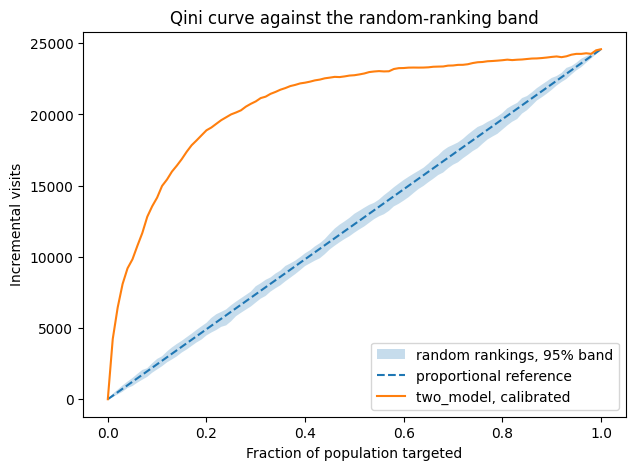

In [28]:
import matplotlib.pyplot as plt


def plot_qini_with_band(run, noise_fraction, noise_curves,
                        estimator="two_model", state="calibrated"):
    """Plot one model's Qini curve over the random-ranking band.

    Args:
        run (dict): Output of run_one_seed.
        noise_fraction (numpy.ndarray): Fraction grid for the band.
        noise_curves (numpy.ndarray): Random-ranking curves.
        estimator (str): Which estimator to plot.
        state (str): Which calibration state to plot.

    Returns:
        matplotlib.axes.Axes: The axes drawn on.
    """
    lower = np.percentile(noise_curves, 2.5, axis=0)
    upper = np.percentile(noise_curves, 97.5, axis=0)

    fraction, values = qini_points(
        run["scores"][(estimator, state)],
        run["test_treatment"],
        run["test_outcome"],
    )

    figure, axes = plt.subplots(figsize=(7, 5))
    axes.fill_between(
        noise_fraction, lower, upper, alpha=0.25,
        label="random rankings, 95% band")
    axes.plot(
        fraction, fraction * values[-1], linestyle="--",
        label="proportional reference")
    axes.plot(fraction, values, label=f"{estimator}, {state}")

    axes.set_xlabel("Fraction of population targeted")
    axes.set_ylabel("Incremental visits")
    axes.set_title("Qini curve against the random-ranking band")
    axes.legend()
    return axes


plot_qini_with_band(run, noise_fraction, noise_curves)
plt.show()

The band is the point of the chart. A curve above the shading found
something. A curve inside the shading did not, however convincing its
shape looks on its own.

## Decisions to record after this step

One line each, from the output above.

1. Did the single model use the treatment input, and what was the
   split share.
2. Qini for each estimator and calibration state, with the spread
   across five seeds.
3. Did any estimator clear the noise band, and by how much.
4. Did calibration change the uplift ranking, and in which direction.
5. Which estimator carries forward into the profit step, and why.

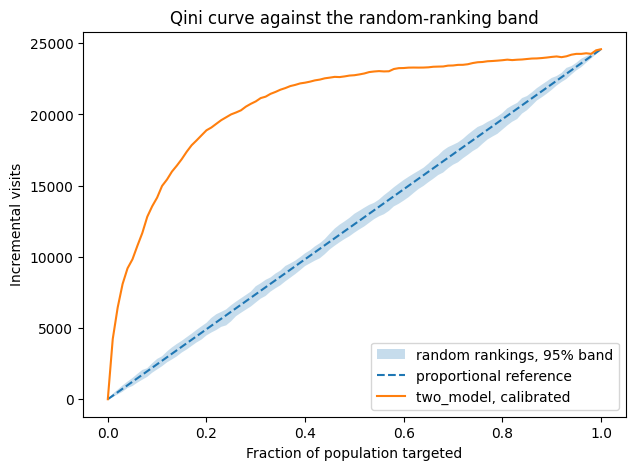

In [29]:
axes = plot_qini_with_band(run, noise_fraction, noise_curves)
axes.figure.savefig("../figures/qini_with_noise_band.png", dpi=150,
                    bbox_inches="tight")